In [1]:
import os
from os import path
from datetime import datetime
import random
import pickle
import pytz

import pandas as pd
import numpy as np

import networkx as nx

from utils.parsing import load_properties, hour_rounder
from utils.parsing import get_contact_list, get_infection_list, get_node_state, create_contact_network, remove_nodes_with_less_edges

## Initial data loading and parsing

In [2]:
# Settings for data analysis

dataset_id = 202
data_format = 3

# Discard transmissions when the infected node was already infected before
discard_reinfections = True

# Default contact time for transmissions that are missing an associated contact event
def_contact_time = 1

# Time delta for animation in seconds, needs to be small in comparison with the total length of the 
# simulation so the changes in the animation are smooth
anim_time_step_min = 10
anim_time_delta_sec = anim_time_step_min * 60

# Time delta for plots in some "natural" time step, for examply, hourly or daily
nat_time_step_min = 24 * 60
nat_time_delta_sec = nat_time_step_min * 60

min_total_contact_time = 0.16  # at least this total time (in minutes) over the two weeks to be defined as in contact
min_total_contact_count = 1 # nodes must have at least this number of edges with other nodes to be kept

# Set a random seed for reproducibility
random_seed = 32
random.seed(random_seed)

# Print warning messages to the console when parsing data
print_data_warnings = False

In [3]:
data_folder = path.join('./data', str(dataset_id))
output_folder = path.join('./output', str(dataset_id))
if not path.exists(output_folder):
    os.makedirs(output_folder)

# Load time properties, which need to be in the file time.properties
# under the data folder with the following structure:
# sim_tz=Europe/London
# time0=Jun 30 2025 8:30AM
# time1=Jun 30 2025 5:30PM
tprops_filename = path.join(data_folder, "time.properties")
tprops = load_properties(tprops_filename)
sim_tz = tprops['sim_tz']
time0 = tprops['time0']
time1 = tprops['time1']

print('Time zone =', sim_tz)
print('Start time =', time0)
print('End time =', time1)

# https://howchoo.com/g/ywi5m2vkodk/working-with-datetime-objects-and-timezones-in-python
# https://itnext.io/working-with-timezone-and-python-using-pytz-library-4931e61e5152
timezone = pytz.timezone(sim_tz)
obs_date0 = timezone.localize(datetime.strptime(time0, '%b %d %Y %I:%M%p'))
obs_date1 = timezone.localize(datetime.strptime(time1, '%b %d %Y %I:%M%p'))

if obs_date0 and obs_date1:
    tmin = datetime.timestamp(obs_date0)
    tmax = datetime.timestamp(obs_date1)
else:
    tmin = min_time
    tmax = max_time

num_nat_intervals = int((nat_time_delta_sec + tmax - tmin) / nat_time_delta_sec + 1)
print("Intervals for time analysis =", num_nat_intervals)

Time zone = Asia/Baghdad
Start time = Nov 16 2025 8:00AM
End time = Nov 30 2025 8:00PM
Intervals for time analysis = 16


In [4]:
# Load participants and histories

all_users = pd.read_csv(path.join(data_folder, "participants_cleaned.csv"), low_memory=False) 
all_events = pd.read_csv(path.join(data_folder, "histories_cleaned.csv"), low_memory=False)
    
users = all_users[all_users["sim_id"] == dataset_id].copy()
if data_format < 2:
    if data_format < 1:
        users['random_id'] = users['id']
else:
    users['random_id'] = users['random_id'].astype(str).str.zfill(4)

# Save the users to a pickle file
with open(path.join(data_folder, 'users.pickle'), 'wb') as f:
    pickle.dump(users, f)

if data_format == 1:
    events = all_events
else:
    events = all_events[all_events["sim_id"] == dataset_id].copy()
    
events.fillna({'contact_length':0, 'peer_id':-1}, inplace=True)
events["event_start"] = events["time"] - events["contact_length"]/1000
events["event_start"] = events["event_start"].astype(int)

p2pToSim = pd.Series(users.sim_id.values, index=users.p2p_id).to_dict()
p2pToId = pd.Series(users.id.values, index=users.p2p_id).to_dict()
idTop2p = pd.Series(users.p2p_id.values, index=users.id).to_dict()
        
user_index = {}
index_user = {}
idx = 0
for kid in idTop2p:
    user_index[kid] = idx
    index_user[idx] = kid
    idx += 1

# Round min and max times to the hour
min_time = min(events['time'])
max_time = max(events['time'])
first_date = hour_rounder(datetime.fromtimestamp(min_time, tz=timezone))
last_date = hour_rounder(datetime.fromtimestamp(max_time, tz=timezone))
min_time = datetime.timestamp(first_date)
max_time = datetime.timestamp(last_date)

print("First event:", first_date)
print("Last event :", last_date)

if time0 and time1:
    print("Start time:", datetime.strptime(time0, '%b %d %Y %I:%M%p'))
    print("End time:", datetime.strptime(time1, '%b %d %Y %I:%M%p'))

print(first_date.tzinfo)

# These should return the same value
print(len(users))
print(len(idTop2p))    
print(len(p2pToId))
print(len(user_index))

First event: 2025-11-15 15:00:00+03:00
Last event : 2025-12-01 18:00:00+03:00
Start time: 2025-11-16 08:00:00
End time: 2025-11-30 20:00:00
Asia/Baghdad
539
539
539
539


At this point, we have parsed the source simulation data and we can use it to extract any information we need from it. For example, in the cell below, we get the final states of all nodes, the list of infections (all the (infectors, infectees) pairs) and the list of all contacts during the entire simulation:

In [5]:
# Get list of infections and contacts, needed to construct the network graph

state = get_node_state(user_index, events, None, p2pToId, data_format, print_data_warnings)
infections = get_infection_list(user_index, events, discard_reinfections, anim_time_delta_sec, p2pToId, data_format, print_data_warnings)
contacts = get_contact_list(user_index, events, infections, def_contact_time, p2pToId, data_format, print_data_warnings)

With the contacts and state information, we can build the network graph using the networkx package. The first step is to construct the full network where we remove isolated nodes:

In [6]:
G = create_contact_network(user_index, contacts, state, "final_health_state", min_total_contact_time)

print(len(G.nodes()), len(G.edges()))

removed = remove_nodes_with_less_edges(G, min_total_contact_count)

isolates = list(nx.isolates(G))
G.remove_nodes_from(isolates)

mask = users.index.isin(removed + isolates)
remids = pd.DataFrame(users[mask]['random_id'].tolist(), columns=['User ID'])
remids.to_csv(path.join(data_folder, 'removed-nodes.csv'), index=False)

print('Removed', len(remids), 'nodes without enough connections')
print('There are', len(G.nodes()), 'remaining nodes with', len(G.edges()), 'edges between them')

539 3295
Removed 97 nodes without enough connections
There are 442 remaining nodes with 3295 edges between them


In [7]:
# Construct a new graph using only the transmission (infection) data
T = nx.DiGraph(infections)

with open(path.join(data_folder, 'transmission-tree.pickle'), 'wb') as f:
    pickle.dump(T, f)

In [8]:
# If the Graph has more than one component, this will return False:
print("Network is connected", nx.is_connected(G))

components = nx.connected_components(G)

subgraphs = [G.subgraph(c) for c in components]
for sg in subgraphs:
    print(len(sg.nodes()), len(sg.edges()))

# Calculate the largest connected component subgraph:
G = sorted(subgraphs, key=lambda x: len(x))[-1]

degrees = [degree for node, degree in G.degree()]

with open(path.join(data_folder, 'network-largest_conn_comp.pickle'), 'wb') as f:
    pickle.dump(G, f)

# Calculating the node positions for the largest connected component
Gpos = nx.spring_layout(G, seed=random_seed)

with open(path.join(data_folder, 'network-node-positions.pickle'), 'wb') as f:
    pickle.dump(Gpos, f)

Network is connected True
442 3295


## Adding additional data to the list of users

In [9]:
users['group'] = users['group'].map({'group1': 1, 'group2': 2})

In [10]:
surv_q_id2title = {35:"S1_Q1", 36:"S1_Q2", 37:"S1_Q3", 38:"S1_Q4", 39:"S1_Q5", 40:"S1_Q6",
                   41:"S2_Q1", 42:"S2_Q2", 43:"S2_Q3", 44:"S2_Q4",
                   55:"S3_Q1", 56:"S3_Q2", 57:"S3_Q3", 58:"S3_Q4", 59:"S3_Q5"}

surv_a_lett2num = {'a':1, 'b':2, 'c':3, 'd':4, 'e':5, 'f':6}

In [11]:
all_survey_answers = pd.read_csv(path.join(data_folder, "survey-answers_cleaned.csv"), low_memory=False) 

In [12]:
survey_answers = all_survey_answers[all_survey_answers["sim_id"] == dataset_id]

In [13]:
qid_values = all_survey_answers.question_id.values
uid_values = all_survey_answers.user_id.values
ans_values = all_survey_answers.value.values

In [14]:
for k in surv_q_id2title:
    users[surv_q_id2title[k]] = np.nan
users['quarantine'] = np.nan
users['no_quarantine'] = np.nan

In [15]:
for uid, qid, ans in zip(uid_values, qid_values, ans_values):
    indices = users.index[users['id'] == uid].tolist()
    qcol = surv_q_id2title[qid]
    qval = surv_a_lett2num[ans]    
    for idx in indices:
        users.at[idx, qcol] = qval

In [16]:
score_events = all_events[['user_id', 'type', 'inf', 'out']]
score_events = score_events[score_events['type'] == 'score'].copy()
score_events['out'] = score_events['out'].astype(float)
print(score_events['inf'].value_counts())

inf
noQuarantine    1494
initPoints       572
quiz             515
escaped          180
quarantine       152
Name: count, dtype: int64


In [17]:
contact_awards = score_events[score_events['inf'] == 'contact']
per_user = contact_awards.groupby('user_id')['out'].agg(scoring_contacts='size',
                                                        contact_points='sum')

users = users.merge(per_user, left_on='id', right_index=True, how='left')
users[['scoring_contacts', 'contact_points']] = users[['scoring_contacts', 'contact_points']].fillna(0)

users['pts_per_contact'] = users['contact_points'] / users['scoring_contacts'].replace(0, np.nan)
users['scoring_contacts_per_active_day'] = users['scoring_contacts'] / users['no_quarantine'].replace(0, np.nan)

# Points forgone per day of quarantine, i.e. the barrier each participant actually faced
users['realized_barrier'] = users['contact_points'] / users['no_quarantine'].replace(0, np.nan)

In [18]:
# Make gender a binary variable, where 0 = Man, 1 = Woman, NA the rest
users['gender'] = np.where(
    users['S1_Q5'] == 1, 0,
    np.where(users['S1_Q5'] == 2, 1, np.nan)
)

In [19]:
dates = []
contacts = []
infections = []
quarantine_no = []
quarantine_yes = []

t = tmin
day = 0
print('Calculating daily counts (infections, quarantine)...')
while t <= tmax:
    t0 = t
    t += nat_time_delta_sec
    td = datetime.fromtimestamp(t, tz=timezone)
    
    # We want to include events that ocurred between t0 and t
    condition = (t0 < events['time']) & (events['time'] <= t)

    tevents = events[condition]
    ctevents = tevents[(tevents['type'] == 'contact')]
    itevents = tevents[(tevents['type'] == 'infection')]
    qtevents = tevents[(tevents['inf'] == 'quarantine')]
    nqtevents = tevents[(tevents['inf'] == 'noQuarantine')]

    date = datetime.fromtimestamp(t0, tz=timezone).strftime('%Y-%m-%d')
    
    users[f'quarantine_day{day}'] = np.nan
    users[f'no_quarantine_day{day}'] = np.nan
    for uid in users.id.values:
        indices = users.index[users['id'] == uid].tolist()
        qindices = qtevents.index[qtevents['user_id'] == uid].tolist()
        nqindices = nqtevents.index[nqtevents['user_id'] == uid].tolist()    
        for idx in indices:
            num_qev_day = len(qindices)
            num_nqev_day = len(nqindices)            
            if 1 < num_qev_day:
                print("  Warning: user", uid, "made", num_qev_day, "quarantine choices in one day")
                num_qev_day = 1
                print(qindices[0], qindices[1:])
            if 1 < num_nqev_day:
                print("  Warning: user", uid, "made", num_nqev_day, "no quarantine choices in one day")
                num_nqev_day = 1
                print(nqindices[0], nqindices[1:])                
            users.at[idx, f'quarantine_day{day}'] = num_qev_day
            users.at[idx, f'no_quarantine_day{day}'] = num_nqev_day

            # users.at[idx, f'quarantine_day{day}'] = min(len(qindices), 1)
            # users.at[idx, f'no_quarantine_day{day}'] = min(len(nqindices), 1)

    date = datetime.fromtimestamp(t0, tz=timezone).strftime('%Y-%m-%d')
    qno = len(nqtevents)
    qyes = len(qtevents)
    inf = len(itevents)
    cont = len(ctevents)

    print(f'day {day}', date, qno, qyes, inf, cont)

    dates.append(date)
    contacts.append(cont)
    infections.append(inf)
    quarantine_no.append(qno)
    quarantine_yes.append(qyes)    
    
    day += 1

last_day = day - 1
print('Done')

daily_counts = pd.DataFrame({'date': dates,
                             'contacts': contacts,
                             'infections': infections,
                             'quarantine_no': quarantine_no, 
                             'quarantine_yes': quarantine_yes})

Calculating daily counts (infections, quarantine)...
day 0 2025-11-16 0 0 0 19583
61589 [61591]
39115 [39128]
65591 [83628]
39196 [39198]
33188 [33192]
40175 [40178]
day 1 2025-11-17 206 43 3 24974
day 2 2025-11-18 187 26 10 23801
122107 [122121]
115657 [115694]
107395 [107397]
107874 [107906]
103310 [103311]
113867 [113869]
day 3 2025-11-19 213 24 7 21296
day 4 2025-11-20 68 8 1 5095
day 5 2025-11-21 97 11 0 2045
132414 [165035]
day 6 2025-11-22 38 0 0 1956
132418 [165042]
154336 [158321]
115722 [159250]
day 7 2025-11-23 111 4 3 9847
169877 [169878]
177358 [177359]
176629 [176630]
176841 [176842]
day 8 2025-11-24 99 11 11 11049
132422 [178821]
191792 [191793]
115741 [192824]
day 9 2025-11-25 143 11 7 11020
132424 [178825]
220470 [220473]
215215 [215468]
day 10 2025-11-26 111 7 6 12695
132426 [205461]
day 11 2025-11-27 52 1 0 1847
day 12 2025-11-28 30 2 0 835
day 13 2025-11-29 25 0 0 371
160838 [232155]
day 14 2025-11-30 111 4 3 6051
Done


In [20]:
# Make sure that all participants have at least a score of 1
users.loc[users['score'] <= 0, 'score'] = 1

In [21]:
# Calculate total quarantine and no quarantine events for each participant by adding daily totals

q_cols = [f"quarantine_day{i}" for i in range(0, last_day+1)]
nq_cols = [f"no_quarantine_day{i}" for i in range(0, last_day+1)]

# Sum across columns (axis=1) for each row
users["quarantine"] = users[q_cols].sum(axis=1)
users["no_quarantine"] = users[nq_cols].sum(axis=1)

In [22]:
# Remove users who did not ever pick quarantine

condition = (users['quarantine'] == 0) & (users['no_quarantine'] == 0)
nusers_before = len(users)

no_q_g1 = len(users[condition & (users['group'] == 1)])
no_q_g2 = len(users[condition & (users['group'] == 2)])

users = users[~condition].copy()
print(f'{nusers_before - len(users)} users removed because they never picked quarantine')
print(f'{no_q_g1} users removed from group 1')
print(f'{no_q_g2} users removed from group 2')
print(f'{no_q_g1 + no_q_g2} users removed in total')

users['total_trials'] = users['quarantine'] + users['no_quarantine']
users['quarantine_rate'] = users['quarantine'] / users['total_trials']

136 users removed because they never picked quarantine
56 users removed from group 1
80 users removed from group 2
136 users removed in total


In [23]:
print(f'Final total number of users to include in analysis: {len(users)}')
print(f'Number of users in group 1: {len(users[users["group"] == 1])}')
print(f'Number of users in group 2: {len(users[users["group"] == 2])}')

Final total number of users to include in analysis: 403
Number of users in group 1: 188
Number of users in group 2: 215


In [24]:
with open(path.join(data_folder, 'users.pickle'), 'wb') as f:
    pickle.dump(users, f)

with open(path.join(data_folder, 'daily_counts.pickle'), 'wb') as f:
    pickle.dump(daily_counts, f)

## Data summaries

In [124]:
infections = events[events["type"] == "infection"]
ilist = {}
for uid, t in zip(infections.user_id.values, infections.time.values):
    ilist[uid] = t

illness = events[events["type"] == "illness"]
slist = {}
for uid, t, i in zip(illness.user_id.values, illness.time.values, illness.inf.values):
    if i == 'symptomatic':
        slist[uid] = t

devices = events.query('type == "modifier" and modifier.str.contains("model:")')
dlist = {}
ios_count = 0
android_count = 0
for uid, dev in zip(devices.user_id.values, devices.modifier.values):
    dlist[uid] = dev
    if 'iPhone' in dev or 'iPad' in dev:
        ios_count += 1
    else:
        android_count += 1

outcomes = events[events["type"] == "outcome"]
elist = {}
qlist = {}
escaped_on_ios = 0
escaped_on_android = 0
for uid, t, o in zip(outcomes.user_id.values, outcomes.time.values, outcomes.out.values):
    if o == 'ESCAPED':        
        elist[uid] = t
        if uid in dlist:
            if 'iPhone' in dlist[uid] or 'iPad' in dlist[uid]:
                escaped_on_ios += 1
            else:
                escaped_on_android += 1
    if o == 'QUIT':
        qlist[uid] = t

for uid in ilist:
    if uid in elist and ilist[uid] < elist[uid]:
        print(uid, 'escaped after becoming infected')
    if uid in qlist and ilist[uid] < qlist[uid]:
        print(uid, 'quit after becoming infected')

print('Participants using iOS devices =', ios_count)
print('Participants using Android devices =', android_count)
print('Infected =', len(ilist))
print('Symptomatic =', len(slist))
print('Escaped =', len(elist))
print('Escaped using iOS device =', escaped_on_ios)
print('Escaped using Android device =', escaped_on_android)
print('Quit =', len(qlist)) 

10036 escaped after becoming infected
9857 escaped after becoming infected
9974 escaped after becoming infected
9892 escaped after becoming infected
Participants using iOS devices = 392
Participants using Android devices = 181
Infected = 50
Symptomatic = 4
Escaped = 143
Escaped using iOS device = 95
Escaped using Android device = 66
Quit = 4


In [125]:
print('Self-reported students', len(users[users['S1_Q6'] == 1.0]))
print('Self-reported faculty', len(users[users['S1_Q6'] == 2.0]))
print('Self-reported staff', len(users[users['S1_Q6'] == 3.0]))
print('Self-reported other affiliation', len(users[users['S1_Q6'] == 4.0]))
print('Self-reported NA affiliation', len(users[users['S1_Q6'] == 5.0]))

Self-reported students 311
Self-reported faculty 16
Self-reported staff 7
Self-reported other affiliation 1
Self-reported NA affiliation 1


In [126]:
print('Self-reported male', len(users[users['S1_Q5'] == 1.0]))
print('Self-reported female', len(users[users['S1_Q5'] == 2.0]))
print('Self-reported other gender', len(users[users['S1_Q5'] == 3.0]))
print('Self-reported NA gender', len(users[users['S1_Q5'] == 4.0]))

Self-reported male 158
Self-reported female 169
Self-reported other gender 4
Self-reported NA gender 5


## Random participant selection

In [127]:
N = 10

In [128]:
with open(path.join(data_folder, 'xids.txt'), 'r') as file:
    xid_list = [line.strip() for line in file]

In [129]:
xid_list

['1856',
 '3429',
 '8627',
 '2669',
 '5612',
 '2508',
 '2300',
 '2061',
 '1120',
 '2193',
 '5740',
 '4324']

In [130]:
eligible_users = users[~users['random_id'].isin(xid_list)].copy()

In [131]:
selected_users = eligible_users.sample(n=N, weights='score', replace=False)

In [132]:
selected_users.random_id.values

array(['0592', '5746', '6833', '6102', '9701', '3651', '4564', '2750',
       '5837', '8793'], dtype=object)

## CONSORT participant-flow diagram

The cell below generates an editable CONSORT-style diagram and exports both vector PDF and high-resolution PNG files to the study output folder.

Important: the cleaned simulation data in this notebook begin after recruitment and randomization. Therefore, recruitment and allocation counts are entered explicitly from the study records rather than inferred from `users`. Update the `flow` dictionary and labels when the unresolved reasons for non-randomization and exclusion from the behavioral analysis have been reconciled. The assertions will stop execution if totals do not agree.

The behavioral analysis population is defined as participants with at least one valid daily quarantine decision. This is more precise than labeling all omitted participants as withdrawals or losses to follow-up.

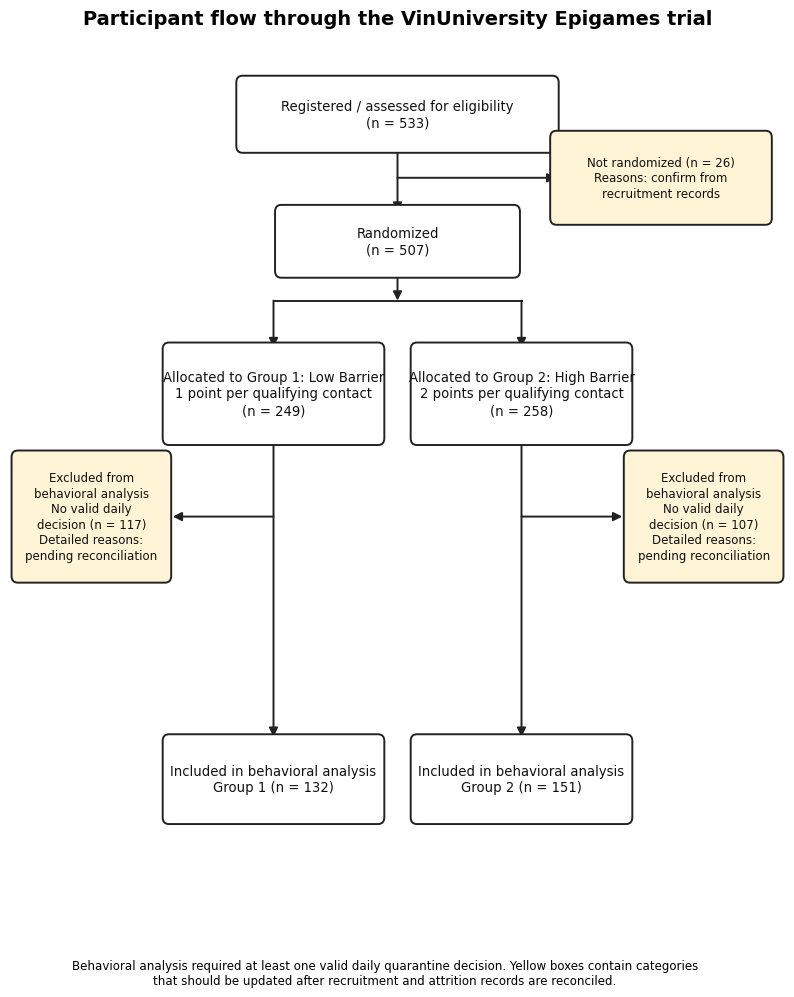

Saved: output/202/consort-participant-flow.pdf
Saved: output/202/consort-participant-flow.png


In [10]:
from pathlib import Path
import textwrap

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

# -----------------------------------------------------------------------------
# Edit participant counts and wording here as study records are reconciled.
# -----------------------------------------------------------------------------
flow = {
    'registered': 533,
    'not_randomized': 26,
    'randomized': 507,
    'g1_allocated': 249,
    'g2_allocated': 258,
    'g1_analyzed': 132,
    'g2_analyzed': 151,
}

flow['g1_not_analyzed'] = flow['g1_allocated'] - flow['g1_analyzed']
flow['g2_not_analyzed'] = flow['g2_allocated'] - flow['g2_analyzed']

labels = {
    'registered': f"Registered / assessed for eligibility\n(n = {flow['registered']})",
    'not_randomized': (
        f"Not randomized (n = {flow['not_randomized']})\n"
        "Reasons: confirm from recruitment records"
    ),
    'randomized': f"Randomized\n(n = {flow['randomized']})",
    'g1_allocated': (
        "Allocated to Group 1: Low Barrier\n"
        f"1 point per qualifying contact\n(n = {flow['g1_allocated']})"
    ),
    'g2_allocated': (
        "Allocated to Group 2: High Barrier\n"
        f"2 points per qualifying contact\n(n = {flow['g2_allocated']})"
    ),
    'g1_not_analyzed': (
        "Excluded from behavioral analysis\n"
        f"No valid daily decision (n = {flow['g1_not_analyzed']})\n"
        "Detailed reasons: pending reconciliation"
    ),
    'g2_not_analyzed': (
        "Excluded from behavioral analysis\n"
        f"No valid daily decision (n = {flow['g2_not_analyzed']})\n"
        "Detailed reasons: pending reconciliation"
    ),
    'g1_analyzed': (
        "Included in behavioral analysis\n"
        f"Group 1 (n = {flow['g1_analyzed']})"
    ),
    'g2_analyzed': (
        "Included in behavioral analysis\n"
        f"Group 2 (n = {flow['g2_analyzed']})"
    ),
}

# Fail early if an edited count makes the participant flow inconsistent.
assert flow['registered'] == flow['not_randomized'] + flow['randomized']
assert flow['randomized'] == flow['g1_allocated'] + flow['g2_allocated']
assert flow['g1_allocated'] == flow['g1_analyzed'] + flow['g1_not_analyzed']
assert flow['g2_allocated'] == flow['g2_analyzed'] + flow['g2_not_analyzed']

processed_users_path = Path(data_folder) / 'users.pickle'
with processed_users_path.open('rb') as handle:
    analysis_users = pickle.load(handle)
# assert flow['g1_analyzed'] + flow['g2_analyzed'] == len(analysis_users), (
#     "Analyzed counts do not match the saved processed users table. "
#     "Re-run preprocessing or update the flow counts."
#  )

# -----------------------------------------------------------------------------
# Drawing helpers and style. Coordinates use a 0-1 figure canvas.
# -----------------------------------------------------------------------------
style = {
    'facecolor': 'white',
    'edgecolor': '#222222',
    'pending_facecolor': '#FFF4D6',
    'line_width': 1.4,
    'font_size': 9.5,
}

def add_box(
    ax, center_x, center_y, width, height, text, *,
    pending=False, wrap_width=38,
):
    patch = FancyBboxPatch(
        (center_x - width / 2, center_y - height / 2),
        width,
        height,
        boxstyle='round,pad=0.008,rounding_size=0.008',
        linewidth=style['line_width'],
        edgecolor=style['edgecolor'],
        facecolor=style['pending_facecolor'] if pending else style['facecolor'],
        zorder=2,
    )
    ax.add_patch(patch)
    ax.text(
        center_x,
        center_y,
        '\n'.join(textwrap.fill(line, wrap_width) for line in text.split('\n')),
        ha='center',
        va='center',
        fontsize=8.5 if pending else style['font_size'],
        color='#111111',
        linespacing=1.25,
        zorder=3,
    )

def add_arrow(ax, start, end):
    ax.add_patch(FancyArrowPatch(
        start,
        end,
        arrowstyle='-|>',
        mutation_scale=13,
        linewidth=style['line_width'],
        color=style['edgecolor'],
        shrinkA=0,
        shrinkB=0,
        zorder=1,
    ))

fig, ax = plt.subplots(figsize=(10, 11))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

# Enrollment and randomization
add_box(ax, 0.50, 0.92, 0.40, 0.075, labels['registered'])
add_box(ax, 0.50, 0.77, 0.30, 0.070, labels['randomized'])
add_box(
    ax, 0.84, 0.845, 0.27, 0.095, labels['not_randomized'],
    pending=True, wrap_width=27,
 )
add_arrow(ax, (0.50, 0.882), (0.50, 0.805))
add_arrow(ax, (0.50, 0.845), (0.705, 0.845))

# Allocation branches
add_arrow(ax, (0.50, 0.735), (0.50, 0.700))
ax.plot(
    [0.34, 0.66], [0.700, 0.700],
    color=style['edgecolor'], linewidth=style['line_width'],
 )
add_arrow(ax, (0.34, 0.700), (0.34, 0.645))
add_arrow(ax, (0.66, 0.700), (0.66, 0.645))
add_box(ax, 0.34, 0.59, 0.27, 0.105, labels['g1_allocated'])
add_box(ax, 0.66, 0.59, 0.27, 0.105, labels['g2_allocated'])

# Direct paths to analysis; side branches show participants not analyzed.
add_arrow(ax, (0.34, 0.537), (0.34, 0.185))
add_arrow(ax, (0.66, 0.537), (0.66, 0.185))
add_arrow(ax, (0.34, 0.445), (0.21, 0.445))
add_arrow(ax, (0.66, 0.445), (0.79, 0.445))
add_box(
    ax, 0.105, 0.445, 0.19, 0.14, labels['g1_not_analyzed'],
    pending=True, wrap_width=22,
 )
add_box(
    ax, 0.895, 0.445, 0.19, 0.14, labels['g2_not_analyzed'],
    pending=True, wrap_width=22,
 )
add_box(ax, 0.34, 0.135, 0.27, 0.090, labels['g1_analyzed'])
add_box(ax, 0.66, 0.135, 0.27, 0.090, labels['g2_analyzed'])

ax.set_title(
    'Participant flow through the VinUniversity Epigames trial',
    fontsize=14,
    fontweight='bold',
    pad=16,
 )

figure_note = (
    "Behavioral analysis required at least one valid daily quarantine decision. "
    "Yellow boxes contain categories that should be updated after recruitment "
    "and attrition records are reconciled."
 )
fig.text(
    0.5, 0.025, textwrap.fill(figure_note, 110),
    ha='center', va='bottom', fontsize=8.5,
 )

consort_base = Path(output_folder) / 'consort-participant-flow'
fig.savefig(consort_base.with_suffix('.pdf'), bbox_inches='tight')
fig.savefig(consort_base.with_suffix('.png'), dpi=600, bbox_inches='tight')
plt.show()

print(f"Saved: {consort_base.with_suffix('.pdf')}")
print(f"Saved: {consort_base.with_suffix('.png')}")